In [31]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("..\..\data\Metadata_features\metadata_features.csv")

df.head()

,img_id,patient_id,lesion_id,gender,skin_cancer_diagnosis,diagnostic,biopsed,mask_components,melanoma_color_count,melanoma_colors,...,convexity_score,lesion_red_share,lesion_green_share,lesion_blue_share,lesion_skin_red_diff,lesion_skin_green_diff,lesion_skin_blue_diff,lesion_skin_rgb_distance,predicted_label,predicted_probability_cancer
0,PAT_684_1303_368.png,PAT_684,1303,MALE,1,BCC,True,2,1,blue_gray,...,0.966073,0.385627,0.316149,0.298224,-4.110664,-4.335522,-3.519299,6.933958,1,0.631991
1,PAT_842_1606_971.png,PAT_842,1606,FEMALE,1,BCC,True,3,1,blue_gray,...,0.968111,0.347777,0.307446,0.344777,-8.710226,-22.357424,-8.463104,25.443006,1,0.742272
2,PAT_113_172_610.png,PAT_113,172,MALE,1,SCC,True,2,2,"red, blue_gray",...,0.982251,0.446228,0.283676,0.270096,7.774562,-7.024822,-2.797506,10.845182,1,0.898004
3,PAT_1633_2855_460.png,PAT_1633,2855,NaN,0,ACK,False,5,0,NaN,...,0.981541,0.425111,0.309371,0.265518,16.566090,18.314028,26.037217,35.885591,0,0.231925
4,PAT_168_262_74.png,PAT_168,262,MALE,1,BCC,True,1,1,blue_gray,...,0.964321,0.417867,0.292136,0.289997,-12.708808,-19.862190,-18.049245,29.695044,1,0.817363


In [ ]:
X = df[['lesion_green_share', 'saturation_variance', 'melanoma_color_count',
       'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score',
       'convexity_score', 'lesion_red_share', 'lesion_skin_green_diff',
       'Polsby-Popper']]
y = df['skin_cancer_diagnosis']

In [23]:
patient_labels = df.groupby("patient_id")["skin_cancer_diagnosis"].max()

patients = patient_labels.index
labels = patient_labels.values

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


train_mask = df["patient_id"].isin(train_patients)
test_mask = df["patient_id"].isin(test_patients)


X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [ ]:
groups_train = df.loc[X_train.index, "patient_id"]

auc_train = []
auc_val = []

n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for n in n_neighbors:

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train, groups_train):

        X_tr = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val_fold)

        model = KNeighborsClassifier(n_neighbors=n)
        model.fit(X_tr_scaled, y_tr)

        # Train AUC
        y_tr_proba = model.predict_proba(X_tr_scaled)[:, 1]
        train_auc = roc_auc_score(y_tr, y_tr_proba)
        train_scores.append(train_auc)

        # Validation AUC
        y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
        val_auc = roc_auc_score(y_val_fold, y_val_proba)
        val_scores.append(val_auc)

    # Average across folds
    auc_train.append(np.mean(train_scores))
    auc_val.append(np.mean(val_scores))

    print(f"n_neighbors = {n} - Train AUC: {auc_train[-1]:.4f} - Val AUC: {auc_val[-1]:.4f}")

n_neighbors = 1 - Train AUC: 1.0000 - Val AUC: 0.6253
n_neighbors = 2 - Train AUC: 0.9315 - Val AUC: 0.6797
n_neighbors = 3 - Train AUC: 0.9042 - Val AUC: 0.7109
n_neighbors = 4 - Train AUC: 0.8833 - Val AUC: 0.7265
n_neighbors = 5 - Train AUC: 0.8660 - Val AUC: 0.7415
n_neighbors = 6 - Train AUC: 0.8562 - Val AUC: 0.7471
n_neighbors = 7 - Train AUC: 0.8494 - Val AUC: 0.7497
n_neighbors = 8 - Train AUC: 0.8425 - Val AUC: 0.7467
n_neighbors = 9 - Train AUC: 0.8372 - Val AUC: 0.7537


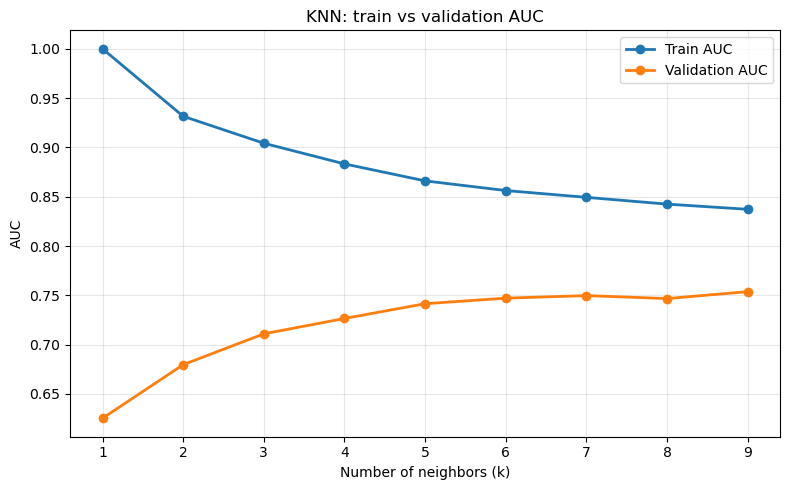

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(n_neighbors, auc_train, "o-", linewidth=2, label="Train AUC")
plt.plot(n_neighbors, auc_val, "o-", linewidth=2, label="Validation AUC")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("AUC")
plt.title("KNN: train vs validation AUC")
plt.xticks(n_neighbors)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
groups_train = df.loc[X_train.index, "patient_id"]

train_accs = []
val_accs = []

n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for n in n_neighbors:

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train, groups_train):

        X_tr = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val_fold)

        model = KNeighborsClassifier(n_neighbors=n)
        model.fit(X_tr_scaled, y_tr)

        # Train accuracy
        y_tr_pred = model.predict(X_tr_scaled)
        train_acc = accuracy_score(y_tr, y_tr_pred)
        train_scores.append(train_acc)

        # Validation accuracy
        y_val_pred = model.predict(X_val_scaled)
        val_acc = accuracy_score(y_val_fold, y_val_pred)
        val_scores.append(val_acc)

    # Average across folds
    train_accs.append(np.mean(train_scores))
    val_accs.append(np.mean(val_scores))

    print(f"n_neighbors = {n} - Train Acc: {train_accs[-1]:.4f} - Val Acc: {val_accs[-1]:.4f}")

n_neighbors = 1 - Train Acc: 1.0000 - Val Acc: 0.6271
n_neighbors = 2 - Train Acc: 0.8246 - Val Acc: 0.6295
n_neighbors = 3 - Train Acc: 0.8305 - Val Acc: 0.6696
n_neighbors = 4 - Train Acc: 0.7900 - Val Acc: 0.6570
n_neighbors = 5 - Train Acc: 0.7800 - Val Acc: 0.6920
n_neighbors = 6 - Train Acc: 0.7651 - Val Acc: 0.6719
n_neighbors = 7 - Train Acc: 0.7639 - Val Acc: 0.6877
n_neighbors = 8 - Train Acc: 0.7551 - Val Acc: 0.6776
n_neighbors = 9 - Train Acc: 0.7572 - Val Acc: 0.6956


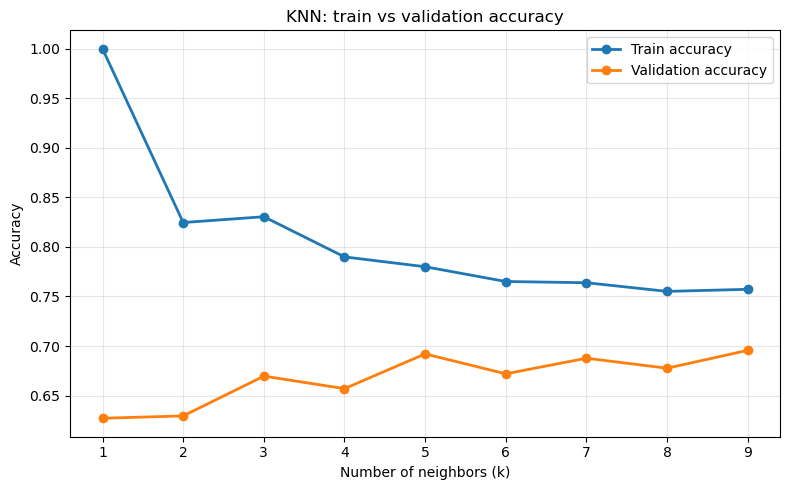

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(n_neighbors, train_accs, marker="o", linewidth=2, label="Train accuracy")
plt.plot(n_neighbors, val_accs, marker="o", linewidth=2, label="Validation accuracy")

plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN: train vs validation accuracy")
plt.xticks(n_neighbors)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()